# Lab 2 — Partner A: what drives the model **overall** (global SHAP)

Module 2 is about *explaining* models, not just fitting them. You own the **global** question:
across the **held-out test hours** the model has never seen, **which features move the prediction the most, and in which direction?**

Your night:
1. Run the setup + SHAP setup (given)
2. Look at the model's **built-in importances** (given) - the quick-but-shallow answer
3. **Write one line** to make the **SHAP beeswarm** - the honest answer (your only coding task)
4. Ship the two PNGs + this notebook through a pull request on branch `dev-global`

> Type the one SHAP line yourself. Module 3 is where we lean on AI tools; today is about *seeing* it.

In [1]:
# --- setup: install SHAP, load the data, fit the model (just run this) ---
!pip install shap -q

import pandas as pd, numpy as np, matplotlib.pyplot as plt, shap
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

url = "https://raw.githubusercontent.com/drdave-teaching/opim5512-lab2-template/main/data/energy_model_data.csv"
df = pd.read_csv(url, parse_dates=["hour"]).sort_values("hour").reset_index(drop=True)  # keep time in order

FEATURES = ["temp_f", "hour_of_day", "dewpoint_f", "humidity_pct", "wind_kt", "weekend"]
X, y = df[FEATURES], df["load_mw"]

# TIME SERIES -> no shuffle: the test set is the most recent 20% of hours (a real forecast, no peeking ahead)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, shuffle=False)
model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1).fit(Xtr, ytr)
print(f"model R2 (test): {r2_score(yte, model.predict(Xte)):.2f}   |   typical miss: {mean_absolute_error(yte, model.predict(Xte)):,.0f} MW")
X.head()

model R2 (test): 0.83   |   typical miss: 662 MW


,temp_f,hour_of_day,dewpoint_f,humidity_pct,wind_kt,weekend
0,65.0,0,51.0,60.49,5.0,0
1,60.0,1,51.0,72.13,4.0,0
2,60.0,2,51.0,72.13,0.0,0
3,55.0,3,51.0,86.35,0.0,0
4,57.0,4,53.0,86.46,4.0,0


### How the model was built (read this — don't code it tonight)

We reused the joined weather + demand data **you built in Lab 1** — one row per hour — and trained a
small **random forest** to predict New England electricity demand from six features. It's accurate
(R² ≈ 0.83 on a held-out, time-ordered test set — a tougher, more honest test than a shuffled split), which makes it worth asking the real question of Module 2: **how does it decide?**

| feature | meaning | units |
|---|---|---|
| `temp_f` | air temperature | deg F |
| `hour_of_day` | 0-23, the hour the reading begins | hour |
| `dewpoint_f` | dew point (muggy-ness) | deg F |
| `humidity_pct` | relative humidity | % |
| `wind_kt` | wind speed | knots |
| `weekend` | 1 on Sat/Sun, else 0 | 0/1 |

**SHAP** answers "how did the model decide" by giving every feature, for every prediction, a number
in **MW**: how much it pushed that prediction **up (+)** or **down (-)** from the average. Add them
all up and you get the model's prediction. That's the whole idea.

In [2]:
# --- SHAP setup (just run this): explain the model on the HELD-OUT test hours ---
explainer = shap.TreeExplainer(model)
shap_values = explainer(Xte)        # explain UNSEEN data (honest) - one row per test hour, one column per feature
print("SHAP ready:", shap_values.shape, "(test hours x features)")

SHAP ready: (149, 6) (test hours x features)


In [8]:
shap_values

.values =
array([[ 2.92865117e+01,  3.19820703e+03,  1.75282939e+02,
         2.45503888e+02, -4.82994092e+01, -2.74707307e+00],
       [-3.59249892e+02,  2.84681361e+03,  1.23756866e+02,
         3.22982277e+00, -7.02989646e+01, -4.51717527e+01],
       [-4.40484779e+02,  2.75263900e+03,  1.18337258e+02,
        -9.90595725e-01, -4.99117665e+01, -1.51236304e+01],
       [-9.53666342e+02,  1.75097796e+03,  7.41568563e+01,
        -4.97926557e+00,  6.34059232e+01,  1.77314557e+01],
       [-1.18855428e+03,  1.00210530e+03,  2.68851445e+01,
        -6.67812145e+01,  1.05498288e+01, -9.66817115e-01],
       [-5.17973873e+02, -9.73647902e+02, -1.99199085e+02,
         2.87197589e+00, -6.32711631e+01,  6.29758608e+01],
       [-3.54656647e+02, -1.11722960e+03, -3.69391665e+01,
         3.19900767e+01,  2.59230505e+01,  8.88290443e+01],
       [-3.69482179e+02, -1.14424894e+03, -9.53463333e+01,
         3.05584180e+01, -7.01183742e+01,  8.86896906e+01],
       [-9.04049975e+02, -1.17623416e+

## 1. The quick answer (given): the model's built-in importances

Every tree model can rank its features. Run this - it saves `importances_builtin.png`.

saved importances_builtin.png


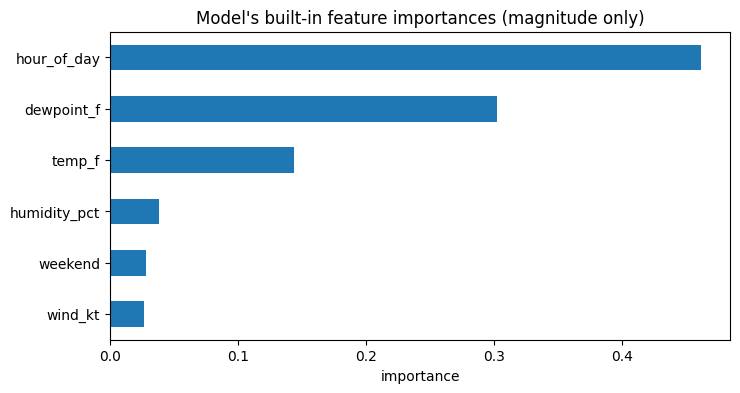

In [3]:
imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
ax = imp.plot.barh(figsize=(8,4), title="Model's built-in feature importances (magnitude only)")
ax.set_xlabel("importance")
ax.get_figure().savefig("importances_builtin.png", dpi=150, bbox_inches="tight")
print("saved importances_builtin.png")

## 2. Your turn: the SHAP beeswarm (one line)

Built-in importances tell you a feature *matters* - but not **which way** it pushes, or for whom.
The SHAP **beeswarm** does: each dot is one test hour, colored by the feature's value, placed by how many
MW it added or removed. **View it first, then save a copy for the report:**

```
shap.plots.beeswarm(shap_values)                  # 1) LOOK at it in the notebook
shap.plots.beeswarm(shap_values, show=False)       # 2) then save a copy for the report
plt.gcf().savefig("shap_global.png", dpi=150, bbox_inches="tight"); plt.close()
```

Then read it: which feature is #1? Do high (red) values push demand up or down? Does SHAP agree
with the built-in ranking above - or reorder it?

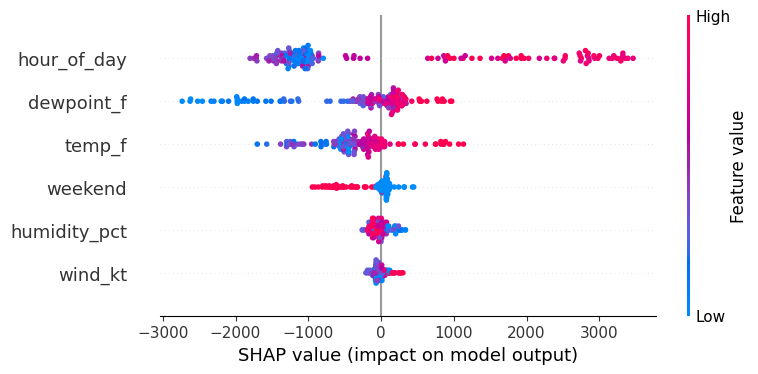

In [10]:
shap.plots.beeswarm(shap_values)
shap.plots.beeswarm(shap_values, show=False)
plt.gcf().savefig("shap_global.png", dpi=150, bbox_inches="tight"); plt.close()


### Download both PNGs to your laptop

In [5]:
import os
from google.colab import files
for p in ['importances_builtin.png', 'shap_global.png']:
    if os.path.exists(p):
        files.download(p)
    else:
        print(f"{p} not found yet - run the cell that makes it, then re-run this one.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

shap_global.png not found yet - run the cell that makes it, then re-run this one.


## Ship it (this is the git half of the lab)

1. **This notebook -> GitHub:** **File -> Save** -> your repo, branch **`dev-global`**, keep the path
   `notebooks/Lab2_A_Global_SHAP.ipynb`, real commit message. (Plain **Save** commits to GitHub because you opened it
   *from* GitHub. Ctrl+S only autosaves to Drive.)
2. **The two PNGs -> your repo:** the download cell put them in your Downloads folder. GitHub Desktop
   -> **Repository -> Show in Explorer** -> drag `importances_builtin.png` and `shap_global.png` into **`images/`**
   (rename any `(1)` copy back first).
3. GitHub Desktop: on branch **`dev-global`** -> **Commit** (real message) -> **Push** ->
   github.com **Compare & pull request** -> ask your partner to review.

## Optional extensions (if you're ahead)

**Same SHAP table, other views.** The beeswarm is just the per-feature *distribution* of SHAP values, so you can draw it as a **boxplot** or **violin** - they show the spread/shape clearly but drop the color (feature value -> direction). And a **dependence scatter** shows how one feature's push changes across its range (color = the strongest interacting feature).

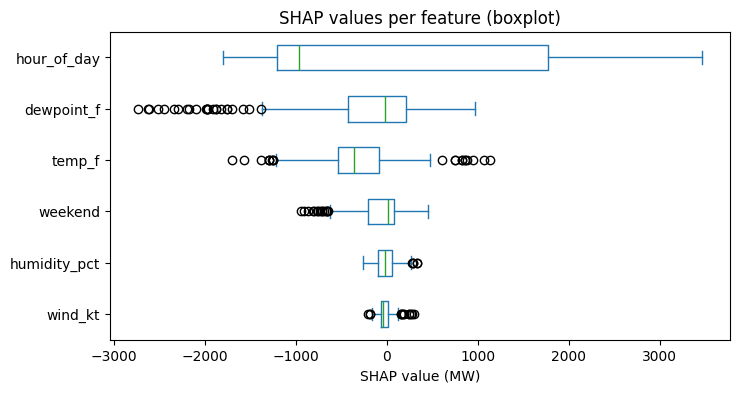

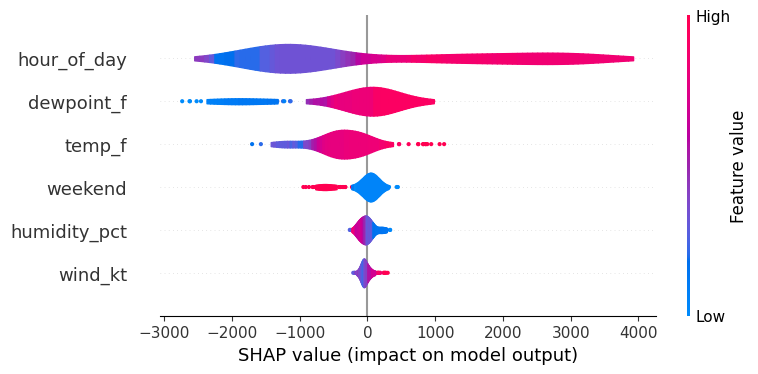

In [6]:
# beeswarm data as a boxplot + a violin
sv = pd.DataFrame(shap_values.values, columns=FEATURES)
order = sv.abs().mean().sort_values().index
sv[order].plot.box(vert=False, figsize=(8,4), title="SHAP values per feature (boxplot)")
plt.xlabel("SHAP value (MW)"); plt.show()
shap.plots.violin(shap_values)

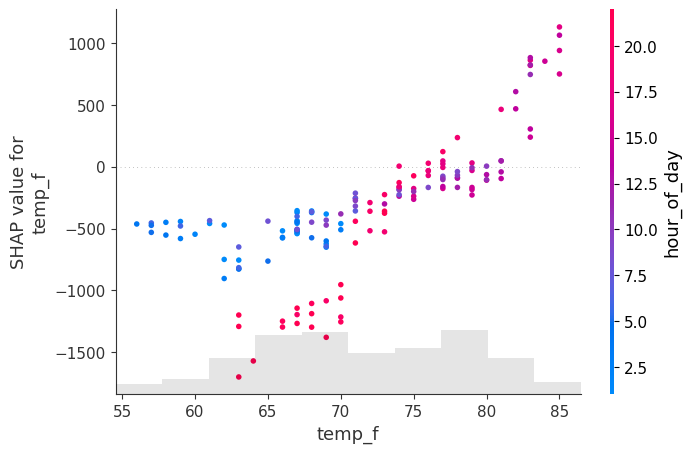

In [7]:
# SHAP dependence scatter (SHAP's partial-dependence view) for the top weather driver
shap.plots.scatter(shap_values[:, "temp_f"], color=shap_values)

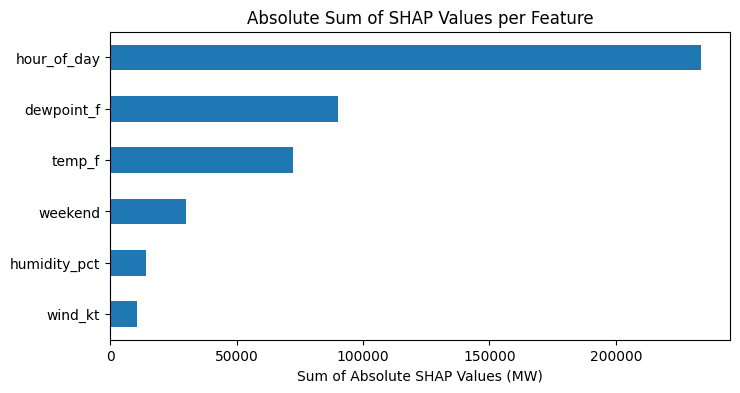

saved shap_abs_sum_bar_plot.png


In [11]:
shap_abs_sum = pd.DataFrame(shap_values.values, columns=FEATURES).abs().sum().sort_values()
ax = shap_abs_sum.plot.barh(figsize=(8,4), title="Absolute Sum of SHAP Values per Feature")
ax.set_xlabel("Sum of Absolute SHAP Values (MW)")
plt.gcf().savefig("shap_abs_sum_bar_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved shap_abs_sum_bar_plot.png")